In [125]:
import os
import cv2
import numpy as np

In [126]:
dataset_path = r"C:\5th Semester\ML\brain tumor , 2 classes"
classes = ["no_tumor", "tumor"]

In [127]:
# the number of instances

total_images = 0

for class_name in classes:
    folder_path = os.path.join(dataset_path, class_name)
    total_images += len(os.listdir(folder_path))

print("Total Images:", total_images)

Total Images: 6183


In [128]:
# Features--> means resizing the images    
img = cv2.resize(img, (128,128))     
img                         

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(128, 128))

In [129]:
print("Features per image is:", 128*128)

Features per image is: 16384


In [130]:
# missing images or corrupted images 
corrupted = 0

for class_name in classes:

    folder_path = os.path.join(dataset_path, class_name)

    for file in os.listdir(folder_path):

        image_path = os.path.join(folder_path, file)

        img = cv2.imread(image_path)

        if img is None:
            corrupted += 1

print("Corrupted Images:", corrupted)
print("Image Shape:", img.shape)

Corrupted Images: 0
Image Shape: (256, 256, 3)


In [131]:
#Anomalies --> check the diminsions of the images
for class_name in classes:

    folder_path = os.path.join(dataset_path, class_name)

    for file in os.listdir(folder_path):

        image_path = os.path.join(folder_path, file)

        img = cv2.imread(image_path)

        print(img.shape)

(630, 630, 3)
(225, 225, 3)
(1080, 1920, 3)
(183, 275, 3)
(256, 256, 3)
(250, 201, 3)
(251, 201, 3)
(243, 236, 3)
(275, 220, 3)
(252, 200, 3)
(512, 512, 3)
(231, 218, 3)
(221, 228, 3)
(225, 208, 3)
(262, 227, 3)
(256, 256, 3)
(225, 225, 3)
(225, 225, 3)
(350, 350, 3)
(243, 207, 3)
(424, 417, 3)
(512, 416, 3)
(217, 232, 3)
(252, 200, 3)
(214, 205, 3)
(251, 201, 3)
(256, 256, 3)
(326, 276, 3)
(380, 336, 3)
(262, 227, 3)
(1024, 1024, 3)
(326, 276, 3)
(222, 212, 3)
(225, 225, 3)
(630, 630, 3)
(442, 442, 3)
(225, 225, 3)
(256, 256, 3)
(848, 785, 3)
(250, 201, 3)
(442, 442, 3)
(225, 225, 3)
(851, 724, 3)
(575, 626, 3)
(227, 235, 3)
(1075, 890, 3)
(328, 267, 3)
(213, 236, 3)
(256, 256, 3)
(512, 512, 3)
(218, 236, 3)
(257, 196, 3)
(872, 850, 3)
(605, 600, 3)
(225, 225, 3)
(725, 728, 3)
(228, 236, 3)
(217, 232, 3)
(278, 208, 3)
(256, 256, 3)
(198, 150, 3)
(300, 227, 3)
(236, 212, 3)
(225, 225, 3)
(236, 214, 3)
(295, 236, 3)
(442, 442, 3)
(442, 409, 3)
(248, 200, 3)
(225, 225, 3)
(256, 256, 3)
(

In [132]:
# For images, traditional correlation matrices are usually not meaningful because each pixel is a feature. -->so does not need to be calculated.


In [133]:
print("Images Loaded:", len(X))

Images Loaded: 6183


In [134]:
X = []
y = []

In [135]:
classes = ["no_tumor", "tumor"]

In [136]:
# Feature Encoding and Label Encoding
for label, class_name in enumerate(classes):

    folder_path = os.path.join(dataset_path, class_name)

    for file in os.listdir(folder_path):

        image_path = os.path.join(folder_path, file)

        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        img = cv2.resize(img, (imagesize, imagesize))

        img = img / 255.0  # --> Normalization

        X.append(img)

        y.append(label)

X = np.array(X)
y = np.array(y)

print("Images Shape:", X.shape)
print("Labels Shape:", y.shape)

Images Shape: (6183, 128, 128)
Labels Shape: (6183,)


In [137]:
X = np.array(X)
y = np.array(y)

# Flatten images for classical ML models
X_flat = X.reshape(X.shape[0], -1)

print("Original Shape:", X.shape)
print("Flattened Shape:", X_flat.shape)

Original Shape: (6183, 128, 128)
Flattened Shape: (6183, 16384)


In [144]:
X_2D = X.reshape(X.shape[0], X.shape[1] * X.shape[2])

print(X_2D.shape)

(6183, 16384)


In [145]:
# training and testing split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_flat,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [146]:
# optionally validation set
X_train, X_temp, y_train, y_temp = train_test_split(X,y,test_size=0.30,random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp,y_temp,test_size=0.50,random_state=42)


In [147]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

In [148]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel="linear", probability=True, random_state=42),
    "Naive Bayes": GaussianNB()
}

In [154]:
print("X_train Shape:", X_train.shape)
print("Dimensions:", X_train.ndim)

X_train Shape: (4328, 128, 128)
Dimensions: 3


In [155]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)

print(X_train.shape)
print(X_test.shape)

(4328, 16384)
(928, 16384)


In [156]:

results = []

for model_name, model in models.items():

    print("Training:", model_name)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([
        model_name,
        accuracy,
        precision,
        recall,
        f1
    ])

    print("\nModel:", model_name)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print("-" * 50)

Training: Logistic Regression

Model: Logistic Regression
Accuracy: 0.9375
Precision: 0.9478827361563518
Recall: 0.9572368421052632
F1 Score: 0.9525368248772504
Confusion Matrix:
[[288  32]
 [ 26 582]]
              precision    recall  f1-score   support

           0       0.92      0.90      0.91       320
           1       0.95      0.96      0.95       608

    accuracy                           0.94       928
   macro avg       0.93      0.93      0.93       928
weighted avg       0.94      0.94      0.94       928

--------------------------------------------------
Training: Decision Tree

Model: Decision Tree
Accuracy: 0.8663793103448276
Precision: 0.9115646258503401
Recall: 0.881578947368421
F1 Score: 0.8963210702341137
Confusion Matrix:
[[268  52]
 [ 72 536]]
              precision    recall  f1-score   support

           0       0.79      0.84      0.81       320
           1       0.91      0.88      0.90       608

    accuracy                           0.87       928
 

In [159]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

In [160]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

In [161]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

print("AUC Score:", roc_auc)

AUC Score: 0.9579409950657896


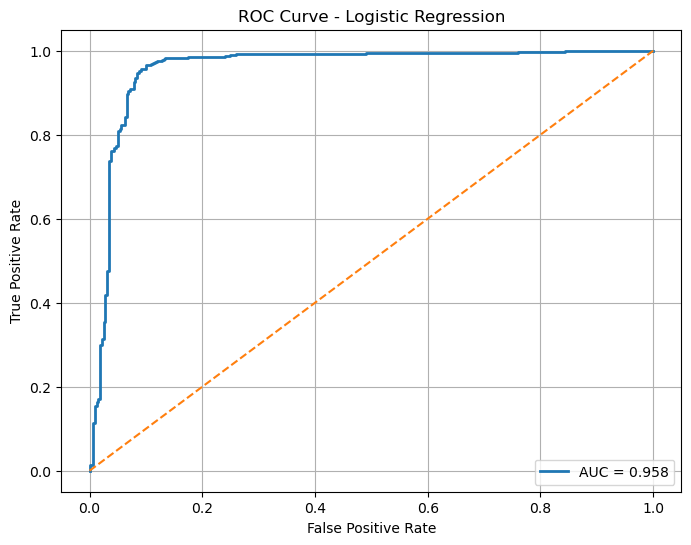

In [162]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()
plt.grid()

plt.show()

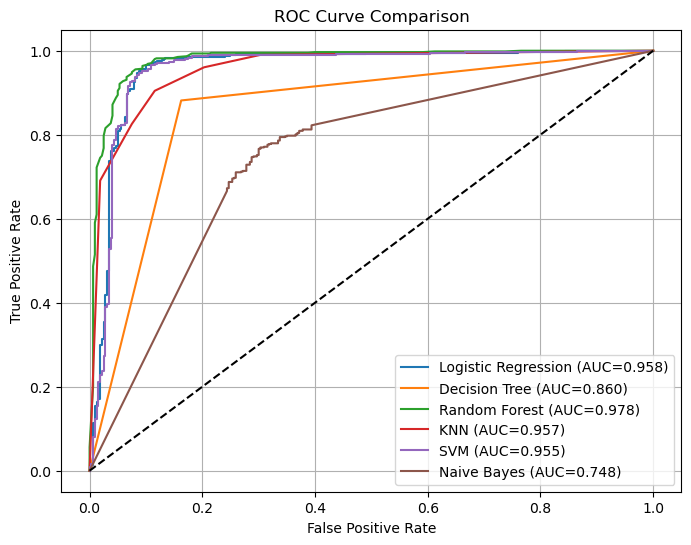

In [163]:
#ROC Curve for All Models Together
plt.figure(figsize=(8,6))

for model_name, model in models.items():

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, y_prob)

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} (AUC={roc_auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.grid()

plt.show()

In [164]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = mse ** 0.5

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 0.0625
MSE : 0.0625
RMSE: 0.25
R² Score: 0.7233552631578948


In [165]:
# CNN -->(samples, height, width, channels)
X_cnn = X.reshape(X.shape[0], 128, 128, 1)

print("CNN Input Shape:", X_cnn.shape)

CNN Input Shape: (6183, 128, 128, 1)


In [166]:
from sklearn.model_selection import train_test_split

X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [169]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [171]:
cnn_model = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=(128,128,1)),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

c:\Users\Mr.user\anaconda3\envs\ml\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [172]:
cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [173]:
history = cnn_model.fit(
    X_train_cnn,
    y_train_cnn,
    epochs=20,
    batch_size=16,
    validation_split=0.20
)

Epoch 1/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 25s 94ms/step - accuracy: 0.8407 - loss: 0.3944 - val_accuracy: 0.8980 - val_loss: 0.2391
Epoch 2/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 18s 72ms/step - accuracy: 0.9247 - loss: 0.2020 - val_accuracy: 0.9222 - val_loss: 0.2232
Epoch 3/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - accuracy: 0.9641 - loss: 0.1034 - val_accuracy: 0.9576 - val_loss: 0.1197
Epoch 4/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 18s 71ms/step - accuracy: 0.9762 - loss: 0.0678 - val_accuracy: 0.9414 - val_loss: 0.1761
Epoch 5/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 23s 94ms/step - accuracy: 0.9856 - loss: 0.0411 - val_accuracy: 0.9657 - val_loss: 0.1144
Epoch 6/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 27s 107ms/step - accuracy: 0.9912 - loss: 0.0238 - val_accuracy: 0.9657 - val_loss: 0.1179
Epoch 7/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 19s 77ms/step - accuracy: 0.9965 - loss: 0.0154 - val_accuracy: 0.9646 - val_loss: 0.1301
Epoch 8/20
248/248 ━━━━━━━━━━━━━━━━━━━━ 27s 110ms/step - accuracy: 0.9952 - loss: 0.0152 

In [174]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

y_prob_cnn = cnn_model.predict(X_test_cnn)

y_pred_cnn = (y_prob_cnn > 0.5).astype("int32")

cnn_accuracy = accuracy_score(y_test_cnn, y_pred_cnn)
cnn_precision = precision_score(y_test_cnn, y_pred_cnn)
cnn_recall = recall_score(y_test_cnn, y_pred_cnn)
cnn_f1 = f1_score(y_test_cnn, y_pred_cnn)

print("CNN Accuracy:", cnn_accuracy)
print("CNN Precision:", cnn_precision)
print("CNN Recall:", cnn_recall)
print("CNN F1 Score:", cnn_f1)

print("Confusion Matrix:")
print(confusion_matrix(y_test_cnn, y_pred_cnn))

print(classification_report(y_test_cnn, y_pred_cnn))

39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step
CNN Accuracy: 0.9692805173807599
CNN Precision: 0.9748803827751196
CNN Recall: 0.9795673076923077
CNN F1 Score: 0.9772182254196643
Confusion Matrix:
[[384  21]
 [ 17 815]]
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       405
           1       0.97      0.98      0.98       832

    accuracy                           0.97      1237
   macro avg       0.97      0.96      0.97      1237
weighted avg       0.97      0.97      0.97      1237



In [177]:
import pandas as pd

# Classical ML Results Table
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

# CNN Result Row
cnn_result = pd.DataFrame(
    [[
        "CNN / ANN",
        cnn_accuracy,
        cnn_precision,
        cnn_recall,
        cnn_f1
    ]],
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ]
)

# Combine Classical ML + CNN Results
final_results = pd.concat(
    [results_df, cnn_result],
    ignore_index=True
)

print("Model Comparison")
print(final_results)

Model Comparison
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.937500   0.947883  0.957237  0.952537
1        Decision Tree  0.866379   0.911565  0.881579  0.896321
2        Random Forest  0.939655   0.929907  0.981908  0.955200
3                  KNN  0.897629   0.936968  0.904605  0.920502
4                  SVM  0.934267   0.949097  0.950658  0.949877
5          Naive Bayes  0.701509   0.839836  0.672697  0.747032
6            CNN / ANN  0.969281   0.974880  0.979567  0.977218
